In [2]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
apple_df = pd.read_csv("/Users/katya/Documents/MMAI S1 2026/MBAN 6110 T - Data Science/Group Assigment - Apple/apple_products_pricing_2020_2026.csv")
apple_df.columns = apple_df.columns.str.strip()

# Quick sanity check
print(apple_df.shape)
print(apple_df.columns.tolist())

(80000, 14)
['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD', 'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']


In [13]:
apple_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  str    
 1   Platform           80000 non-null  str    
 2   Product_Category   80000 non-null  str    
 3   Model_Name         80000 non-null  str    
 4   Condition          80000 non-null  str    
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   str    
 11  Stock_Status       80000 non-null  str    
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 8.5 MB


In [15]:
# numeric ranges
# USD prices
min_launch_price_usd = apple_df['Launch_Price_USD'].min()
max_launch_price_usd = apple_df['Launch_Price_USD'].max()
min_current_price_usd = apple_df['Current_Price_USD'].min()
max_current_price_usd = apple_df['Current_Price_USD'].max()

# INR prices
min_launch_price_inr = apple_df['Launch_Price_INR'].min()
max_launch_price_inr = apple_df['Launch_Price_INR'].max()
min_current_price_inr = apple_df['Current_Price_INR'].min()
max_current_price_inr = apple_df['Current_Price_INR'].max()

# Discounts
min_discount = apple_df['Discount_Pct'].min()
max_discount = apple_df['Discount_Pct'].max()

# Ratings
min_rating = apple_df['Rating'].min()
max_rating = apple_df['Rating'].max()
min_reviews_count = apple_df['Reviews_Count'].min()
max_reviews_count = apple_df['Reviews_Count'].max()

# Dates - start with converting to date type
apple_df['Date'] = pd.to_datetime(apple_df['Date']) 

min_date = apple_df['Date'].min()
max_date = apple_df['Date'].max()

# Unique values
unique_platform = apple_df['Platform'].unique()
unique_product_category = apple_df['Product_Category'].unique()
unique_model_name = apple_df['Model_Name'].unique()
unique_condition = apple_df['Condition'].unique()
unique_sale_event = apple_df['Sale_Event'].unique()
unqiue_stock_status = apple_df['Stock_Status'].unique()




In [16]:
# Print everything

print(
    f"Date range: {min_date} to {max_date}\n"
    f"Launch Price USD range: {min_launch_price_usd} to {max_launch_price_usd}\n"
    f"Current Price USD range: {min_current_price_usd} to {max_current_price_usd}\n"
    f"Launch Price INR range: {min_launch_price_inr} to {max_launch_price_inr}\n"
    f"Current Price INR range: {min_current_price_inr} to {max_current_price_inr}\n"
    f"Discount range: {min_discount} to {max_discount}\n"
    f"Rating range: {min_rating} to {max_rating}\n"
    f"Reviews Count range: {min_reviews_count} to {max_reviews_count}\n"
    f"Unique Platforms: {unique_platform}\n"
    f"Unique Product Categories: {unique_product_category}\n"
    f"Unique Model Names: {unique_model_name}\n"
    f"Unique Conditions: {unique_condition}\n"
    f"Unique Sale Events: {unique_sale_event}\n"
    f"Unique Stock Statuses: {unqiue_stock_status}\n"
)

# This dataset goes from 2020 to 2026
# 

Date range: 2020-09-19 00:00:00 to 2026-07-31 00:00:00
Launch Price USD range: 329 to 1999
Current Price USD range: 109.93 to 2038.97
Launch Price INR range: 32242 to 195902
Current Price INR range: 9157.68 to 203668.71
Discount range: -2.0 to 73.1
Rating range: 3.8 to 4.9
Reviews Count range: 10 to 11526
Unique Platforms: <StringArray>
['Flipkart', 'Amazon']
Length: 2, dtype: str
Unique Product Categories: <StringArray>
['Watch', 'iPad', 'iPhone', 'Mac']
Length: 4, dtype: str
Unique Model Names: <StringArray>
[     'Apple Watch Series 6 (44mm)',          'iPad Air (4th Gen) 64GB',
                   'iPhone 12 64GB',              'iPhone 12 Pro 128GB',
             'MacBook Air M1 256GB',      'iPad Pro 11-inch (M1) 128GB',
                  'iPhone 13 128GB',          'iPhone 13 Pro Max 256GB',
              'iPad (9th Gen) 64GB',      'Apple Watch Series 7 (45mm)',
 'MacBook Pro 14-inch M1 Pro 512GB',          'iPad Air (5th Gen) 64GB',
             'MacBook Air M2 256GB',      'App

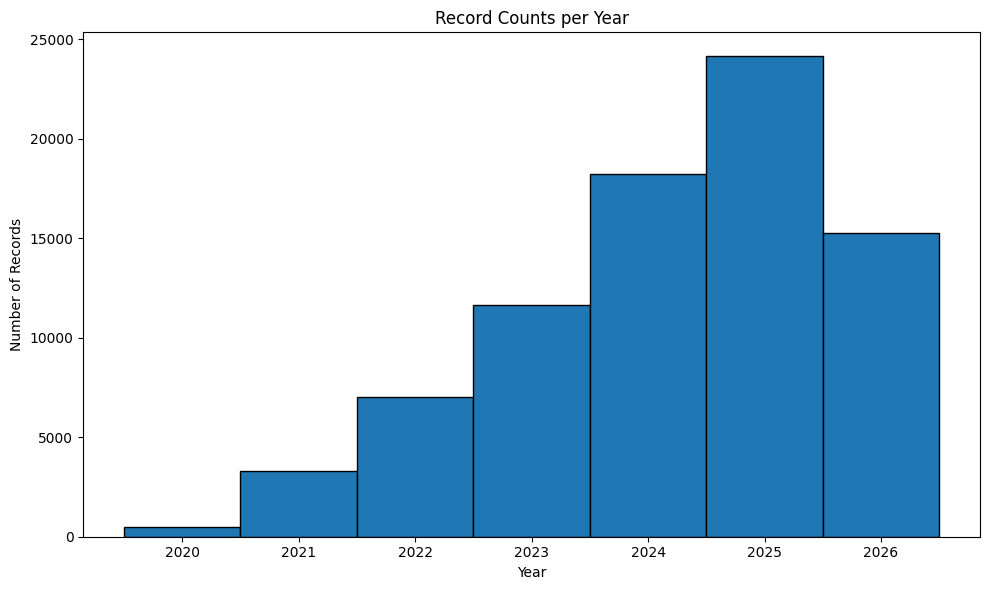

In [17]:
# Data counts per year

years = apple_df['Date'].dt.year

plt.figure(figsize=(10, 6))
plt.hist(years, bins=range(years.min(), years.max() + 2), edgecolor='black', align='left')
plt.title('Record Counts per Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(range(years.min(), years.max() + 1))
plt.tight_layout()
plt.show()

# Obseration: we have a lot more data from 2024 onwards, so we should keep not of that in our analysis.

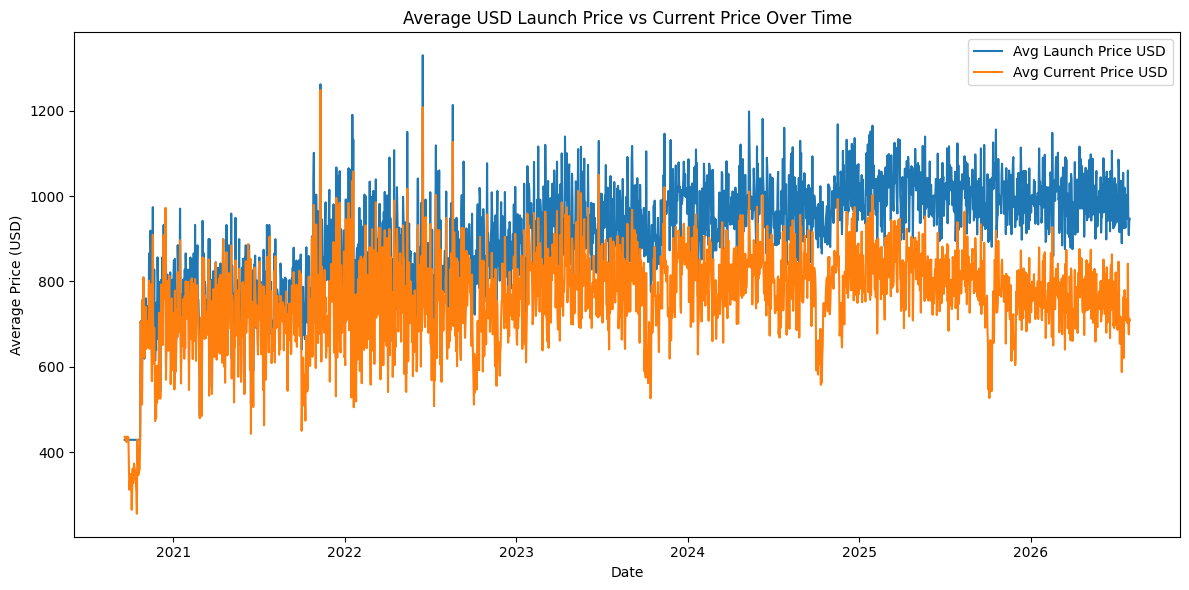

In [18]:
# Show average USD prices comparing average launch price vs. average current price over time.

apple_daily_prices = apple_df.groupby('Date', observed=True).agg(
    avg_launch_price_usd=('Launch_Price_USD', 'mean'),
    avg_current_price_usd=('Current_Price_USD', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(apple_daily_prices['Date'], apple_daily_prices['avg_launch_price_usd'], label='Avg Launch Price USD')
plt.plot(apple_daily_prices['Date'], apple_daily_prices['avg_current_price_usd'], label='Avg Current Price USD')
plt.title('Average USD Launch Price vs Current Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

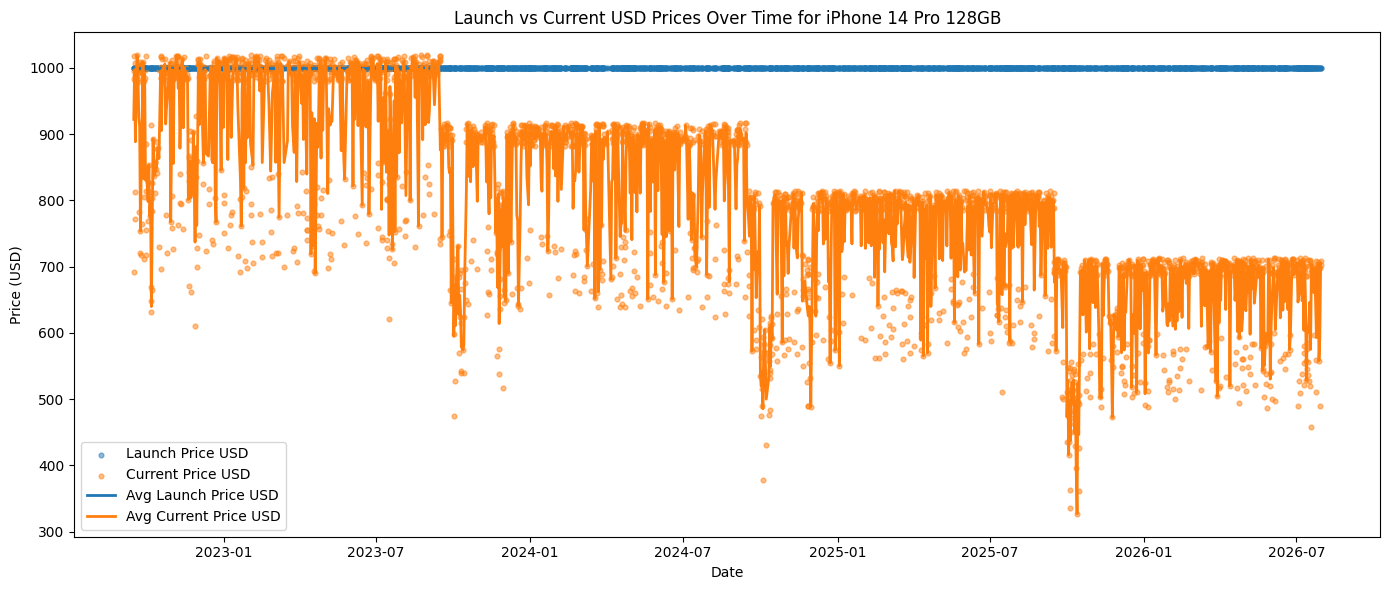

In [19]:
popular_model = apple_df['Model_Name'].value_counts().idxmax()
popular_df = apple_df[apple_df['Model_Name'] == popular_model].sort_values('Date')

daily_avg = popular_df.groupby('Date', observed=True).agg(
    avg_launch_price_usd=('Launch_Price_USD', 'mean'),
    avg_current_price_usd=('Current_Price_USD', 'mean')
).reset_index()

plt.figure(figsize=(14, 6))
plt.scatter(popular_df['Date'], popular_df['Launch_Price_USD'],
            label='Launch Price USD', color='tab:blue', alpha=0.5, s=12)
plt.scatter(popular_df['Date'], popular_df['Current_Price_USD'],
            label='Current Price USD', color='tab:orange', alpha=0.5, s=12)

plt.plot(daily_avg['Date'], daily_avg['avg_launch_price_usd'],
         color='tab:blue', linewidth=2, label='Avg Launch Price USD')
plt.plot(daily_avg['Date'], daily_avg['avg_current_price_usd'],
         color='tab:orange', linewidth=2, label='Avg Current Price USD')

plt.title(f'Launch vs Current USD Prices Over Time for {popular_model}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

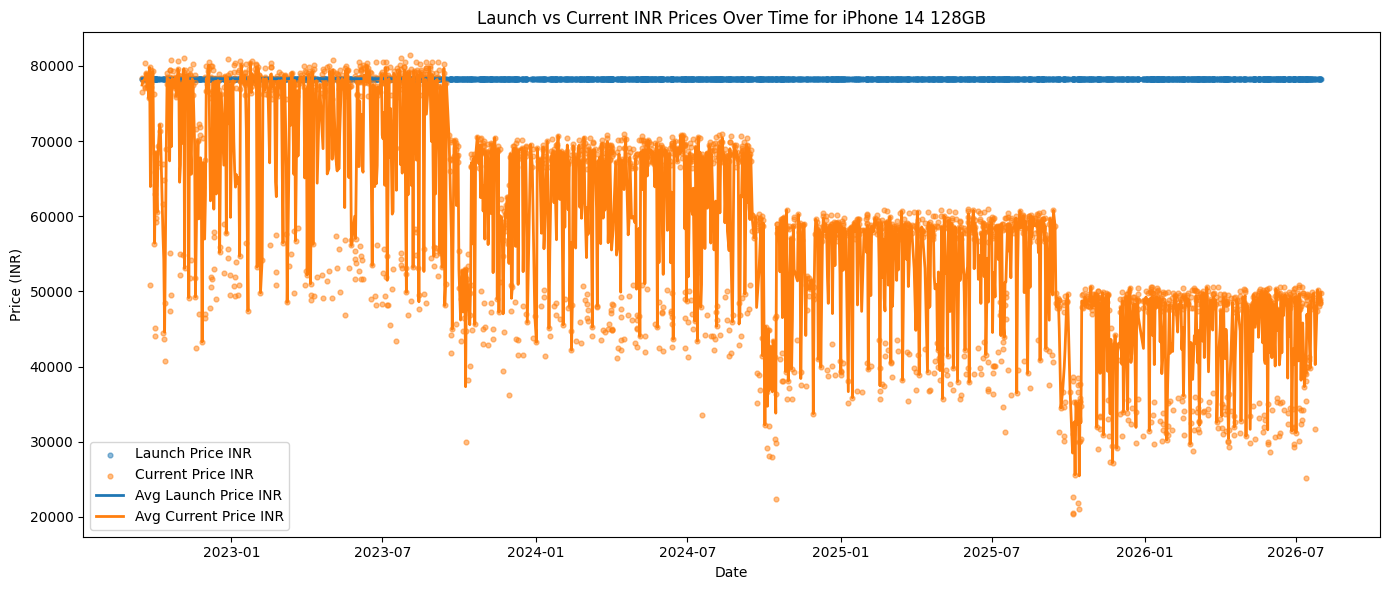

In [20]:
iphone14_df = apple_df[apple_df['Model_Name'] == 'iPhone 14 128GB'].sort_values('Date')

daily_avg_inr = iphone14_df.groupby('Date', observed=True).agg(
    avg_launch_price_inr=('Launch_Price_INR', 'mean'),
    avg_current_price_inr=('Current_Price_INR', 'mean')
).reset_index()

plt.figure(figsize=(14, 6))
plt.scatter(iphone14_df['Date'], iphone14_df['Launch_Price_INR'],
            label='Launch Price INR', color='tab:blue', alpha=0.5, s=12)
plt.scatter(iphone14_df['Date'], iphone14_df['Current_Price_INR'],
            label='Current Price INR', color='tab:orange', alpha=0.5, s=12)

plt.plot(daily_avg_inr['Date'], daily_avg_inr['avg_launch_price_inr'],
         color='tab:blue', linewidth=2, label='Avg Launch Price INR')
plt.plot(daily_avg_inr['Date'], daily_avg_inr['avg_current_price_inr'],
         color='tab:orange', linewidth=2, label='Avg Current Price INR')

plt.title('Launch vs Current INR Prices Over Time for iPhone 14 128GB')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()